In [2]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
EQUATIONS  = CONFIGS['experiments']['sr']['optimizedeqs']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'
CANDRUN    = 'sr_all'
CANDSEED   = 102
CANDCOMPLEXITY = 15
CANDLABEL  = 'SR-ALL-15'
PCLABEL    = 'SR-ALL-15-PC'
NBINS      = 20
MINSAMPLES = 50
MINPRECIP  = 0.1
LANDFRAC   = 0.5
NHOURBINS  = 8
REGISTRY   = {row['name']:json.loads(row['constants']) for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}
CANDEQ     = pd.read_csv(os.path.join(MODELSDIR,'sr',f'{CANDRUN}_{CANDSEED}_equations.csv')).set_index('complexity').loc[CANDCOMPLEXITY,'equation']

In [4]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def calc_moisture_term(rh):
    return kappa*(rh-rhmean)

def calc_instability_term(thetae,thetaestar):
    return thetae-gamma*thetaestar-thetac

def calc_thetae_weight(lf,consts):
    return consts['lamthetae']*((consts['lfc']-lf)**3+consts['pc']*(1-consts['lfc'])**3)

def calc_shf_weight(lf,consts):
    return consts['lamshf']*(consts['lfc']-lf)**3

def calc_correction_term(thetae,shf,lf,consts):
    return calc_thetae_weight(lf,consts)*(thetae-thetaemean)+calc_shf_weight(lf,consts)*(shf-shfmean)-consts['beta']

def calc_r2(pred,target,mask):
    return 1-np.sum((pred[mask]-target[mask])**2)/np.sum((target[mask]-target[mask].mean())**2)

def to_precip(exponent):
    return np.maximum(np.expm1(exponent),0.0)

def bin_2d(x,y,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges[0])-1,0,len(edges[0])-2)
    yi     = np.clip(np.digitize(y,edges[1])-1,0,len(edges[1])-2)
    shape  = (len(edges[0])-1,len(edges[1])-1)
    counts = np.zeros(shape)
    sums   = np.zeros(shape)
    np.add.at(counts,(xi,yi),1)
    np.add.at(sums,(xi,yi),z)
    return np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

def calc_time_mean(z,finite,shape):
    return np.nanmean(np.where(finite,z,np.nan).reshape(shape),axis=0)

def calc_local_hour_bin(hours,lon,shape,nbins=NHOURBINS):
    localhour = (hours[:,None,None]+lon[None,None,:]/15.0)%24
    return (np.broadcast_to(localhour,shape).ravel()//(24/nbins)).astype(int)

def bin_by_hour(hourbin,z,mask,nbins=NHOURBINS):
    counts = np.bincount(hourbin[mask],minlength=nbins)
    sums   = np.bincount(hourbin[mask],weights=z[mask],minlength=nbins)
    return sums/np.maximum(counts,1)

def wrap_cycle(x,y,period=24):
    return np.r_[x[-1]-period,x,x[0]+period],np.r_[y[-1],y,y[0]]

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
c3,c4,c5 = (REGISTRY['sr_atm_eq'][name] for name in ['c3','c4','c5'])

lam        = STATS['tp_std']*c3/STATS['thetae_std']**3
gamma      = c4*STATS['thetae_std']/STATS['thetaestar_std']
thetac     = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+c5*STATS['thetae_std']
kappa      = STATS['thetae_std']/STATS['rh_std']
rhmean     = STATS['rh_mean']
thetaemean = STATS['thetae_mean']
shfmean    = STATS['shf_mean']

cshf,clfc  = -float(re.findall(r'-?\d+\.\d+',CANDEQ)[0]),float(re.findall(r'-?\d+\.\d+',CANDEQ)[1])
assert CANDEQ==f'sr_atm_eq + ((thetae - (shf * {-cshf:.8g})) * cube({clfc:.8g} - lf))'
models = {'SR-ALL':(REGISTRY['sr_all_eq']['c9'],REGISTRY['sr_all_eq']['c10'],REGISTRY['sr_all_eq']['c11'],0.0),
          'SR-ALL-PC':(REGISTRY['sr_all_pc_eq']['c12'],REGISTRY['sr_all_pc_eq']['c13'],REGISTRY['sr_all_pc_eq']['c14'],1.0),
          CANDLABEL:(cshf,clfc,0.0,0.0),
          PCLABEL:(cshf,clfc,0.0,1.0)}
consts = {name:dict(lamthetae=STATS['tp_std']/STATS['thetae_std'],lamshf=STATS['tp_std']*value/STATS['shf_std'],lfc=lfc,beta=STATS['tp_std']*beta,pc=pc)
          for name,(value,lfc,beta,pc) in models.items()}

print(f'{CANDLABEL}: {CANDEQ}')
print(f'{PCLABEL}: sr_atm_eq + (thetae + {cshf:.4g}*shf)*cube({clfc:.4g} - lf) + cube(1 - {clfc:.4g})*thetae')
physical = pd.DataFrame({name:{'lambda (1/K)':c['lamthetae'],
                               'gamma (K m2/W)':c['lamshf']/c['lamthetae'],
                               'theta0 (K)':thetaemean+c['lamshf']/c['lamthetae']*shfmean,
                               'LFc':c['lfc'],
                               'beta':c['beta'],
                               'theta_e weight, LF=0 (1/K)':calc_thetae_weight(0.0,c),
                               'theta_e weight, LF=1 (1/K)':calc_thetae_weight(1.0,c)} for name,c in consts.items()}).T
display(physical.style.format('{:.4g}'))

SR-ALL-15: sr_atm_eq + ((thetae - (shf * -5.6251073)) * cube(0.6989902 - lf))
SR-ALL-15-PC: sr_atm_eq + (thetae + 5.625*shf)*cube(0.699 - lf) + cube(1 - 0.699)*thetae


,lambda (1/K),gamma (K m2/W),theta0 (K),LFc,beta,"theta_e weight, LF=0 (1/K)","theta_e weight, LF=1 (1/K)"
SR-ALL,0.05816,1.127,358.1,0.73,0.06341,0.02263,-0.001145
SR-ALL-PC,0.05816,1.12,358,0.73,0.07398,0.02377,0
SR-ALL-15,0.05816,1.209,359.2,0.699,0,0.01986,-0.001586
SR-ALL-15-PC,0.05816,1.209,359.2,0.699,0,0.02145,0


In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = (ds.sizes[dim] for dim in ['time','lat','lon'])
    lat,lon,dsig    = ds['lat'].values,ds['lon'].values,ds['dsig'].values
    hours  = ds['time'].dt.hour.values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp,shf = (ds[name].transpose('time','lat','lon').values.ravel() for name in ['tp','shf'])
    lf     = xr.broadcast(ds['lf'],ds['tp'])[0].transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals   = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
moisture    = calc_moisture_term(integrals['rh'])
instability = calc_instability_term(integrals['thetae'],integrals['thetaestar'])
thetaeanom  = integrals['thetae']-thetaemean
atmexp      = lam*np.maximum(moisture,instability)**3
atmtp       = to_precip(atmexp)
corrections = {name:calc_correction_term(integrals['thetae'],shf,lf,consts[name]) for name in consts}
predtp      = {name:to_precip(atmexp+corrections[name]) for name in consts}
pc2grad     = {name:np.where(moisture>=instability,0.0,3*lam*instability**2)+calc_thetae_weight(lf,consts[name]) for name in consts}
finite      = np.isfinite(moisture)&np.isfinite(instability)&np.isfinite(corrections[PCLABEL])&np.isfinite(tp)
pctp        = predtp[PCLABEL]
favorable   = finite&(atmtp>=MINPRECIP)
regionmasks = {'Ocean':lf<LANDFRAC,'Land':lf>=LANDFRAC}

skill = pd.DataFrame({name:{**{f'R2 {region}':calc_r2(values,tp,finite&mask) for region,mask in {**regionmasks,'All':finite}.items()},
                            'PC2 (%)':100*np.mean(pc2grad[name][finite]>=0) if name in pc2grad else 100.0}
                      for name,values in {'SR-ATM':atmtp,**predtp}.items()}).T
display(skill.style.format({'R2 Ocean':'{:.3f}','R2 Land':'{:.3f}','R2 All':'{:.3f}','PC2 (%)':'{:.1f}'}))

,R2 Ocean,R2 Land,R2 All,PC2 (%)
SR-ATM,0.351,0.302,0.334,100.0
SR-ALL,0.509,0.293,0.415,88.7
SR-ALL-PC,0.509,0.294,0.416,100.0
SR-ALL-15,0.514,0.306,0.424,88.5
SR-ALL-15-PC,0.518,0.309,0.427,100.0


In [7]:
shape       = (ntime,nlat,nlon)
hourbin     = calc_local_hour_bin(hours,lon,shape)
hourcenters = (np.arange(NHOURBINS)+0.5)*24/NHOURBINS
gain        = calc_time_mean((atmtp-tp)**2,finite,shape)-calc_time_mean((pctp-tp)**2,finite,shape)
cycles      = {(region,source):wrap_cycle(hourcenters,bin_by_hour(hourbin,values,finite&regionmask))
               for region,regionmask in regionmasks.items() for source,values in [('ERA5',tp),('SR-ATM',atmtp),(PCLABEL,pctp)]}

oceanmask  = favorable&regionmasks['Ocean']
edges      = (np.linspace(*np.percentile(shf[oceanmask],[1,99]),NBINS+1),np.linspace(*np.percentile(thetaeanom[oceanmask],[1,99]),NBINS+1))
centers    = [0.5*(edge[:-1]+edge[1:]) for edge in edges]
gridshf,gridthetae = np.meshgrid(np.linspace(edges[0][0],edges[0][-1],200),np.linspace(edges[1][0],edges[1][-1],200))
weights    = 1+atmtp[oceanmask]
lfvalues,lfindex = np.unique(lf[oceanmask],return_inverse=True)
lfweights  = np.bincount(lfindex,weights=weights)
made       = sum(lfweight*np.exp(calc_correction_term(gridthetae+thetaemean,gridshf,lfvalue,consts[PCLABEL])) for lfvalue,lfweight in zip(lfvalues,lfweights))/weights.size-weights.mean()
needed     = bin_2d(shf[oceanmask],thetaeanom[oceanmask],(tp-atmtp)[oceanmask],edges).T

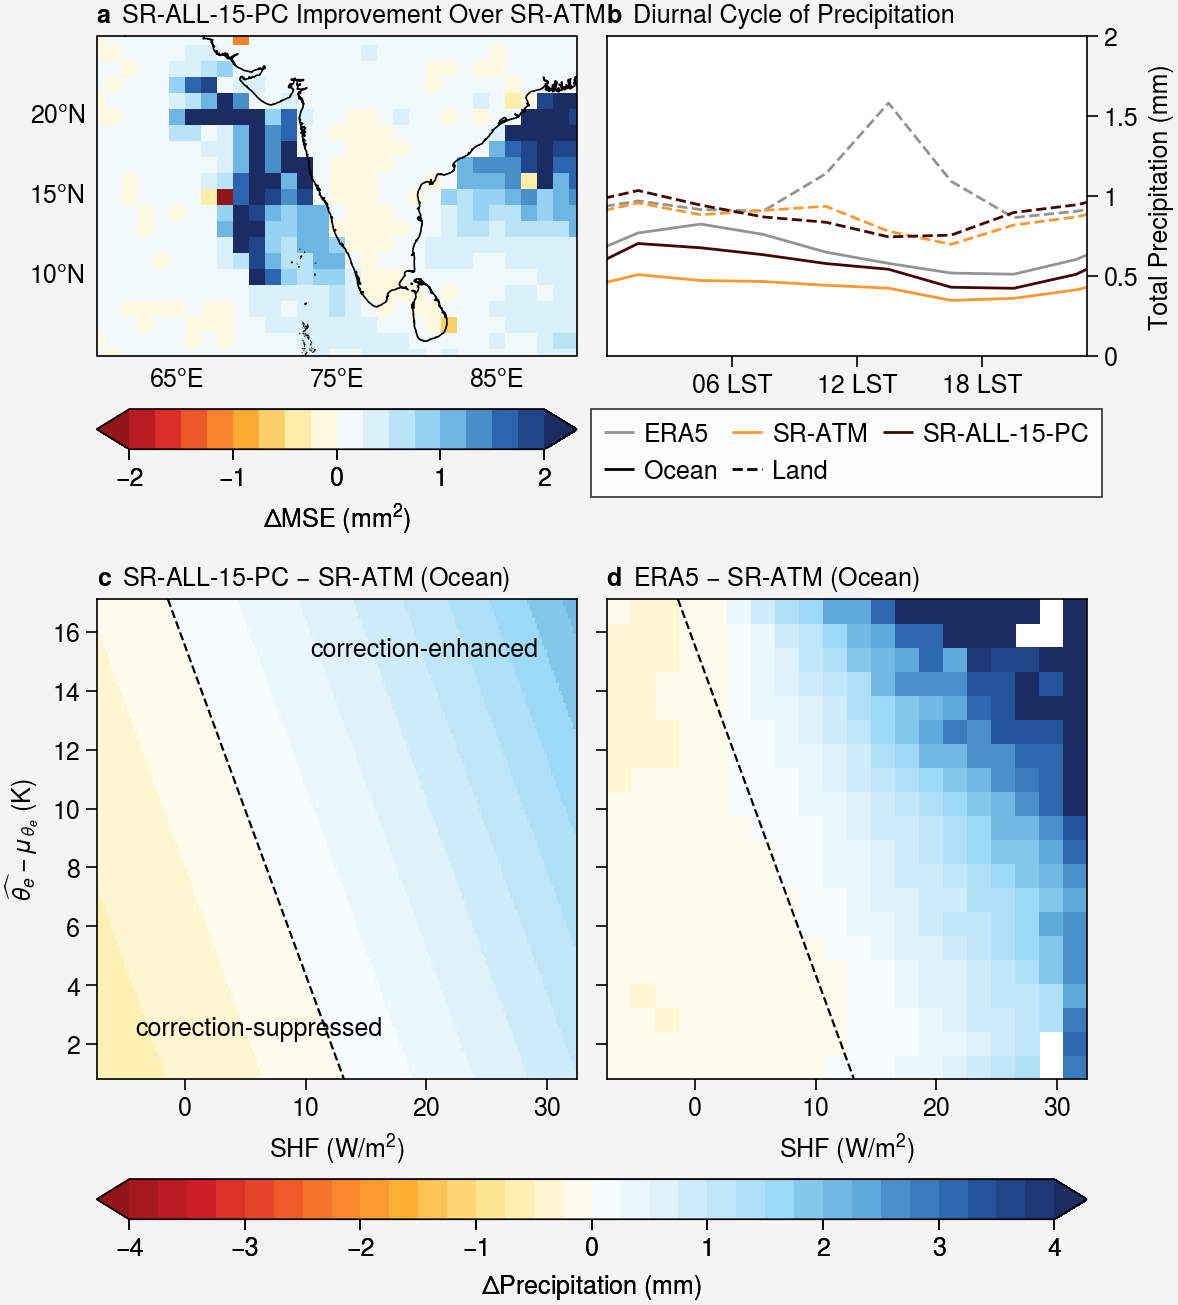

In [8]:
colors  = {'ERA5':'gray','SR-ATM':EQUATIONS['sr_atm_eq']['color'],PCLABEL:EQUATIONS['sr_all_pc_eq']['color']}
styles  = {'Ocean':'-','Land':'--'}
handles = [Line2D([],[],color=color,linewidth=1,label=label) for label,color in colors.items()]
handles+= [Line2D([],[],color='k',linestyle=linestyle,linewidth=1,label=region) for region,linestyle in styles.items()]

fig,axs = pplt.subplots([[1,2],[3,4]],refwidth=2.4,hratios=(1,1.5),proj={1:'cyl'},share=False,span=False,wspace=1.2,hspace=6)
axs[0].format(title=f'{PCLABEL} Improvement Over SR-ATM',coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',latlim=LATRANGE,latlines=[10,15,20],latlabels='l')
axs[1].set_box_aspect((LATRANGE[1]-LATRANGE[0])/(LONRANGE[1]-LONRANGE[0]))
axs[1].format(title='Diurnal Cycle of Precipitation',xlim=(0,23),xticks=[6,12,18],xticklabels=['06 LST','12 LST','18 LST'],
              ylabel='Total Precipitation (mm)',ylim=(0,2),yticks=0.5,ytickloc='right',yticklabelloc='right',ylabelloc='right')
for ax in axs[2:]:
    ax.set_box_aspect(1)
    ax.format(xlabel='SHF (W/m$^2$)',xlim=(edges[0][0],edges[0][-1]),ylim=(edges[1][0],edges[1][-1]))
axs[2].format(title=f'{PCLABEL} $-$ SR-ATM (Ocean)',ylabel='$\\widehat{\\mathit{\\theta_e}}-\\mathit{\\mu_{\\theta_e}}$ (K)')
axs[3].format(title='ERA5 $-$ SR-ATM (Ocean)',yticklabels=[])

mgain = axs[0].pcolormesh(lon,lat,gain,cmap='ColdHot_r',vmin=-2,vmax=2,levels=16,extend='both')
axs[0].colorbar(mgain,loc='b',ticks=1,label='$\\Delta$MSE (mm$^2$)')
for (region,source),(x,y) in cycles.items():
    axs[1].plot(x,y,color=colors[source],linestyle=styles[region],linewidth=1)
axs[1].legend(handles,loc='b',ncols=3,columnspacing=0.6,handlelength=1.2,handletextpad=0.4)
mcorr = axs[2].pcolormesh(gridshf,gridthetae,made,cmap='ColdHot_r',vmin=-4,vmax=4,levels=32,extend='both')
axs[3].pcolormesh(*centers,needed,cmap='ColdHot_r',vmin=-4,vmax=4,levels=32,extend='both')
for ax in axs[2:]:
    ax.contour(gridshf,gridthetae,made,levels=[0],colors='k',linewidths=0.8,linestyles='--')
axs[2].text(0.92,0.92,'correction-enhanced',ha='right',va='top',transform=axs[2].transAxes)
axs[2].text(0.08,0.08,'correction-suppressed',ha='left',va='bottom',transform=axs[2].transAxes)
fig.colorbar(mcorr,loc='b',cols=(1,2),ticks=1,space=4,label='$\\Delta$Precipitation (mm)')
fig.format(abc=True,titleloc='l',grid=False)
pplt.show()